# Assessment to selection

In [1]:
from pathlib import Path

from stocksift.assessment import StockAssessment
from stocksift.policy import (
    LongEqualFeatureScore,
    LongEqualGroupScore,
    LongFeatureScore,
    LongGroupScore,
    LongThresholdFilter,
    evaluate_selection
)

In [2]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260814.csv"
RATIO_CSV = "kospi200_ratios_260814.csv"

In [3]:
# Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(price_csv=PRICE_CSV, ratio_csv=RATIO_CSV, data_root=DATA_DIR)
prices = assessment.prices

In [4]:
date = '2025-09-01'
features = assessment.assess(date)
print(f"Assessment universe: {len(features)}")

Assessment universe: 200


In [5]:
threshold = LongThresholdFilter()
threshold.trace(features)

,step,feature,operator,threshold,remaining
0,0,initial_universe,,<NA>,200
1,1,per_hist_pct,<=,80.0,107
2,2,eps_growth_pct,>=,20.0,78
3,3,momentum_12m_pct,>=,20.0,64


In [6]:
eligible = threshold.select(features)

#candidates = LongEqualFeatureScore(top_n=20)
candidates = LongEqualGroupScore(top_n=20)

selected = candidates.select(features, tickers=eligible['ticker'])
selected.head()

,ticker,as_of_date,price,BPS,PER,PBR,EPS,DIV,DPS,per_smoothed,...,momentum_12m_pct,volatility_60d,max_drawdown_12m,volatility_risk_pct,drawdown_risk_pct,valuation_score,fundamentals_score,momentum_score,selection_score,selection_rank
0,443060,2025-09-01,204000.0,17402.0,38.46,11.72,5304.0,1.54,3150.0,37.300,...,89.847716,0.427518,-0.356853,52.261307,70.351759,65.775291,86.666667,87.853151,80.098369,1
1,012450,2025-09-01,916000.0,108184.0,19.91,8.47,46002.0,0.38,3500.0,19.335,...,95.431472,0.497394,-0.329328,68.341709,62.311558,42.614606,96.052915,89.634928,76.100816,2
2,267260,2025-09-01,487000.0,41725.0,34.95,11.67,13935.0,1.10,5350.0,35.250,...,79.695431,0.475213,-0.404494,64.321608,81.909548,56.490642,90.492232,80.504281,75.829052,3
3,062040,2025-09-01,106200.0,14292.0,33.86,7.43,3136.0,0.40,420.0,36.685,...,93.908629,0.590233,-0.454657,84.924623,88.944724,45.980417,90.655284,90.388658,75.674786,4
4,006800,2025-09-01,18758.0,20662.0,12.19,0.91,1545.0,1.33,250.0,11.860,...,91.370558,0.539227,-0.241348,77.889447,31.155779,47.782559,83.665590,94.422653,75.290267,5


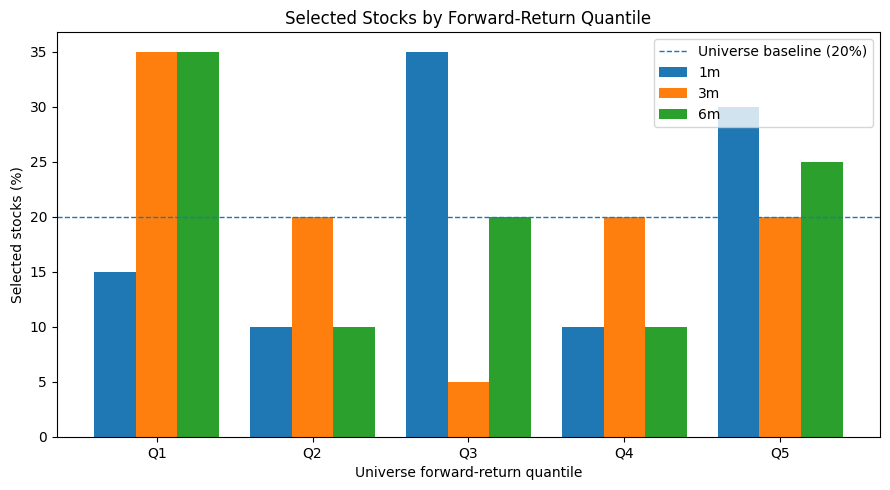

In [7]:
kw = dict(
    horizons = [1,3,6],
    plot = 'distribution',
    universe = features, 
    prices = prices
)
_ = evaluate_selection(selected, **kw)

# Recipes

In [1]:
from stocksift.assessment import StockAssessment
from stocksift.policy import (
    LongThresholdFilter as LongFilter, 
    LongEqualFeatureScore as LongFeature,
    LongEqualGroupScore as LongGroup
)
from stocksift.recipes import apply_selection, evaluate_recipe

In [2]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260814.csv"
RATIO_CSV = "kospi200_ratios_260814.csv"

In [3]:
# 1. Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(
    price_csv=PRICE_CSV, 
    ratio_csv=RATIO_CSV, 
    data_root=DATA_DIR
)

*Rule variants*

In [4]:
ft1 = [
    ("per_hist_pct", "<=", 50.0),
    ("eps_growth_pct", ">=", 50.0),
    ("momentum_12m_pct", ">=", 50.0),
]

ft2 = [
    ("per_hist_pct", "<=", 80.0),
    ("eps_growth_pct", ">=", 20.0),
    ("momentum_12m_pct", ">=", 20.0),
]

v1 = {
    "per_hist_pct": "lower",
    "pbr_hist_pct": "lower",
}

v2 = {
    "per_expansion_pct": "lower",
    "pbr_expansion_pct": "lower",
}


f1 =  {
    "eps_growth_pct": "higher",
    "bps_growth_pct": "higher",
    #"dps_growth_pct": "higher",
}

m1 = {
    "momentum_6m_pct": "higher",
    #"momentum_12m_pct": "higher",
}

In [5]:
n = 20

#policies = [LongFilter(ft2)]
#policies = [LongFeature(f1, top_n=n)]
#policies = [LongFeature(v2, top_n=n)]
#policies = [LongFeature(m1, top_n=n)]
##policies = [LongFilter(ft1)]
##policies = [LongFeature(v1, top_n=n)]

#policies = [LongFilter(ft2), LongFeature(f1, top_n=n)]
#policies = [LongFilter(ft2), LongFeature(v2, top_n=n)]
#policies = [LongFilter(ft2), LongFeature(m1, top_n=n)]
##policies = [LongFilter(ft2), LongFeature(v1, top_n=n)]

In [6]:
n = 10

make_group = lambda v, f, m=None: LongGroup({
    'valuation': v, 'fundamentals': f, **({} if m is None else {'momentum': m}),
}, top_n=n)

policies = [LongFilter(ft2), make_group(v2, f1, m1)]
#policies = [LongFilter(ft2), make_group(v1, f1, m1)]
#policies = [LongFilter(ft2), make_group(v2, f1)]
#policies = [LongFilter(ft2), make_group(v1, f1)]
#policies = [make_group(v2, f1, m1)]
#policies = [make_group(v1, f1)]
#policies = [make_group(v2, f1)]
#policies = [LongFilter(ft1), make_group(v2, f1, m1)]

Selected: 200 -> 64 -> 10


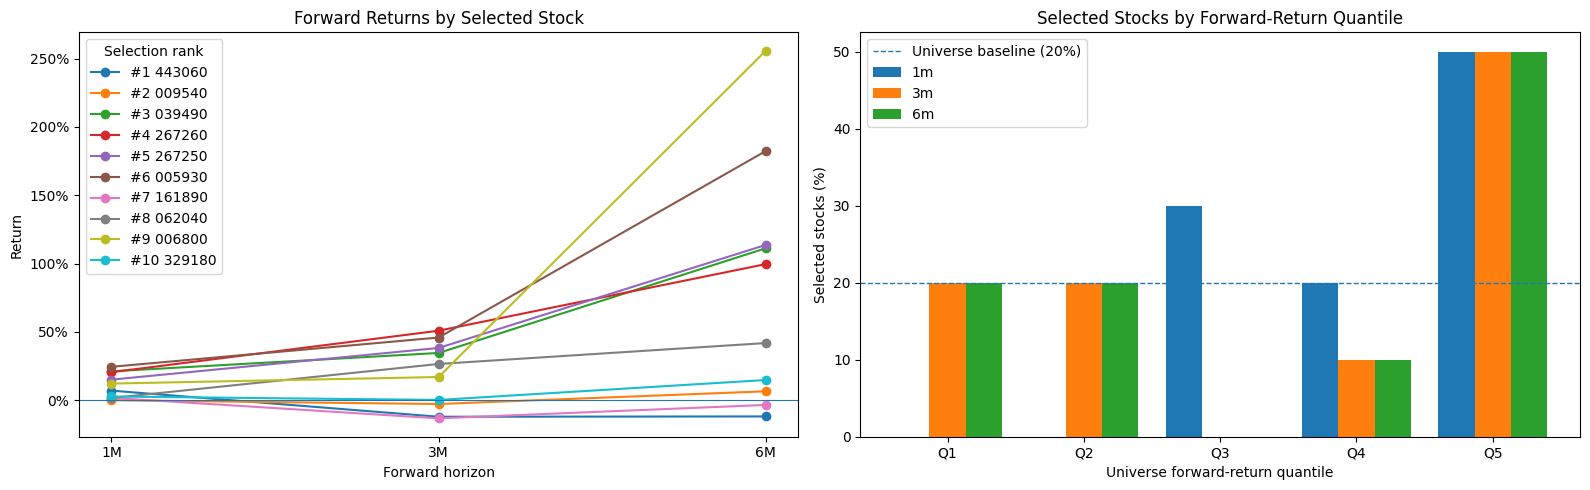

In [7]:
kw = dict(
    as_of = '2025-09-01',
    policies = policies,
    horizons = [1,3,6],
)

_ = evaluate_recipe(
    assessment, **kw,
    plot='both'#plot='distribution',
)

In [8]:
result = evaluate_recipe(
    assessment, **kw,
    result="summary",
)
result

Selected: 200 -> 64 -> 10


,horizon,selected_count,universe_count,selected_mean_return,universe_mean_return,mean_excess_return,selected_median_return,universe_median_return,median_excess_return,top_quantile_hit_rate,bottom_quantile_hit_rate,quantile_baseline_rate,selected_mean_percentile
0,1m,10,200,0.106432,0.027256,0.079177,0.096003,0.007716,0.088287,0.5,0.0,0.2,76.475
1,3m,10,200,0.185136,0.124728,0.060408,0.217602,0.070458,0.147144,0.5,0.2,0.2,58.100
2,6m,10,200,0.810380,0.440851,0.369529,0.707137,0.297526,0.409612,0.5,0.2,0.2,60.100


In [16]:
#result.to_dict()

# Trajectory

In [1]:
from stocksift.assessment import StockAssessment
from stocksift.policy import LongThresholdFilter, LongEqualGroupScore
from stocksift.recipes import apply_selection, selection_trajectory
from stocksift.charts import browse_price_chart, browse_price_comparison

In [2]:
DATA_DIR = '../pf/data'
PRICE_CSV = "kospi200_prices_260814.csv"
RATIO_CSV = "kospi200_ratios_260814.csv"
TICKER_NAME_CSV = 'kospi200_const_20260828.csv'

In [3]:
# 1. Produce the canonical ticker-level assessment feature table.
assessment = StockAssessment(
    price_csv=PRICE_CSV, 
    ratio_csv=RATIO_CSV, 
    ticker_name_csv=TICKER_NAME_CSV, 
    data_root=DATA_DIR
)

In [4]:
date = None
features = assessment.assess(date)
print(f"Assessment universe: {len(features)}")

Assessment universe: 200


In [5]:
policies = [LongThresholdFilter(), LongEqualGroupScore()]

In [6]:
selected = apply_selection(features, policies)
tickers = selected['ticker'].to_list()

Selected: 200 -> 90 -> 10


In [9]:
kw = dict(
    top_n = 10, freq = 10, periods = 5,
    as_of = None, policies = policies
)

selection_trajectory(assessment, style=True, **kw)

Selection trajectory:   0%|          | 0/5 [00:00<?, ?it/s]

,2026-06-18,2026-07-02,2026-07-16,2026-07-31,2026-08-14
rank,,,,,
1,002380,483650,483650,483650,483650
2,082740,002380,278470,278470,007660
3,329180,082740,002380,002380,278470
4,042660,329180,082740,066570,062040
5,278470,278470,071050,036570,002380
6,064350,007660,066570,009540,192820
7,071050,071050,007660,003230,298040
8,007660,064350,030200,071050,082740
9,017960,042660,329180,329180,329180


In [51]:
#prices = assessment.prices

In [7]:
from stocksift.naver import fetch_naver_ohlcv

prices = fetch_naver_ohlcv(
    tickers,
    start="2025-01-01",
)

Fetching OHLCV:   0%|          | 0/10 [00:00<?, ?ticker/s]

In [8]:
kw = dict(
    ticker_names = assessment.ticker_names
)

browse_price_chart(prices, tickers, freq='W', **kw)

In [9]:
browse_price_comparison(prices, tickers, **kw)

# testing

In [1]:
from stocksift.naver import fetch_naver_ohlcv

In [2]:
tickers = ["005930", "000660", "005380"]

df = fetch_naver_ohlcv(
    tickers,
    start="2025-01-01",
)

Fetching OHLCV:   0%|          | 0/3 [00:00<?, ?ticker/s]

In [7]:
import pandas as pd
f = 'del/test_ohlcv.csv'
#prices.to_csv(f)
prices = pd.read_csv(f, dtype={'ticker':str})
tickers = prices['ticker'].drop_duplicates().to_list()
prices = prices.set_index(['date','ticker'])